> 🚨 **Folders required before running this Notebook: Building Block `.xyz` Files**

- `NODE_FILES` *(.xyz, required)*  
  Files containing the node fragments / higher-connectivity building units.  
  **Location:** `0_node/` directory  
  **Default behavior:** The required number of node files depends on the selected `TOPO`:  
  - `hcb` / `sql` / `kgm`: exactly one `.xyz` file must be present  
  - `hcb_ab`: exactly two `.xyz` files must be present  
  Otherwise, provide explicit paths via `input_nodes=[...]`.

- `LINKER_FILES` *(.xyz, topology-dependent)*  
  Files containing the linker fragments / lower-connectivity building units.  
  **Location:** `0_linker/` directory  
  **Default behavior:** The required number of linker files depends on the selected `TOPO`:  
  - `hcb` / `sql` / `kgm`: exactly one `.xyz` file must be present  
  - `hcb_ab`: no linker file is required; files in `0_linker/` are ignored  
  Pass `input_linkers=[]` to explicitly provide no linkers, or provide explicit paths via `input_linkers=[...]`.

> 🚨 **Building Block Requirements**
>
> - **Dummy atoms are required at every intended connection site.**  
>   Each position at which a bond will be formed in the final COF must be marked by a dummy atom in the input building block.
>
> - **Dummy atom encoding**
>   - `He` = connection site (all bonds are treated as single)
>
> - **Important**  
>   Dummy atoms are used only to define the connection sites during construction. They do not represent real atoms in the final COF structure.


In [1]:
import coflandscaper as cl

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


### General Settings & Options

#### Structural Parameters

- `TOPOLOGY` *(str, required, default: None)*  
  Defines the underlying network topology.  
  **Allowed values:** `hcb`, `sql`, `hcb_ab`, `kgm`  
  - `hcb` / `sql` / `kgm`: require one node file and one linker file  
  - `hcb_ab`: requires two node files and no linker file

#### Naming Parameters

- `COF_NAME` *(str, required, default: None)*  
  Unique identifier for the generated structure.  
  All output files and directories will be named using this value.  
  **Constraints:**  
  - Should be unique within the working directory.  
  - Avoid spaces and special characters for compatibility.

#### Stacking Parameters

- `MODE` *(str, required, default: None)*  
  Defines the stacking mode(s) to be generated.  
  **Allowed values:**  
  - `incl` → inclined stacking  
  - `serr` → serrated stacking  
  - `both` → generate both stacking modes

  **Behavior:**  
  Selecting `both` will generate both configurations sequentially and store them in the corresponding output structure.


In [3]:
TOPOLOGY = "hcb"
COF_NAME = "COF-1"
MODE = "both"

### Single-Layer COF Construction & Pre-Optimization

This step generates the single-layer COF structure and performs MACE pre-optimization.

> **Practical note:** If the input building-block fragments are strongly non-planar, the generated stacking matrix can contain strained or sterically congested geometries. Starting from relatively planar building units is therefore recommended, followed by relaxation of the assembled framework. Because the isolated single-layer model has more conformational freedom than the final stacked COF, the preoptimized layer may twist more strongly than the corresponding bulk structure. The generated matrix should be inspected for unphysical close contacts before downstream screening.

In [5]:
builder = cl.BuildCOF2D()
builder.build(topo=TOPOLOGY, cof_name=COF_NAME)

>>> == Min RMSD of (node type: 0, node bb: example_node): 9.36E-05
>>> Pre-location at node slot 0, (node type: 0, node bb: example_node), RMSD: 9.36E-05
>>> Pre-location at node slot 1, (node type: 0, node bb: example_node), RMSD: 9.36E-05
>>> Topology optimization starts.
>>> MESSAGE: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
>>> SUCCESS: True
>>> ITER: 10
>>> OBJ: 0.000
>>> Location at node slot 0, (node type: 0, node bb: example_node), RMSD: 8.04E-05
>>> Location at node slot 1, (node type: 0, node bb: example_node), RMSD: 8.29E-05
>>> Start placing edges.
/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/spatial/transform/_rotation.py:2586: UserWarning: Optimal rotation is not uniquely or poorly defined for the given sets of vectors.
  q, rssd, sensitivity = backend.align_vectors(a, b, weights, return_sensitivity)
>>> Start finding bonds in generated framework.
>>> Start finding bonds in building blocks.
>>> Start fi

['COF-1/1_COF-1_single_layer/COF-1_unopt.cif']

In [6]:
preopt = cl.MaceOpt()
preopt.run_preopt(cof_name=COF_NAME)

       Step     Time          Energy          fmax
LBFGS:    0 15:15:15   -31213.656676        2.514812


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.004580711214139e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:    1 15:15:16   -31214.385979        0.989446


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.011294547731139e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:    2 15:15:17   -31214.595625        0.982338


...

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 2.9708512994479176e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:   21 15:15:31   -31216.392660        0.010121


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.006499226448148e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:   22 15:15:32   -31216.392685        0.006974
Converged


True

### ILD × ILS Structure Matrix Generation

This step generates stacked COF structures by systematically varying:

- **Interlayer Distance (ILD)** (default range: 3.0-4.0 A in steps of 0.1 A)  
- **Interlayer Slipping (ILS)** (default range: 0.0 A to the AB limit in steps of 1.0 A)  
  Default ILS shift length and angle are auto-computed from the topology; use `print_shift=True` to display them.

The input structure is the pre-optimized single-layer (AA stacking with large interlayer distance).  
This step converts it into physically meaningful bulk stacking configurations.

Generated stacked structures organized by mode:  
- `.../serr/` → serrated stacking configurations  
- `.../incl/` → inclined stacking configurations  

These structures are intended for subsequent single-point energy evaluations and energy landscape analysis.


In [7]:
matrix = cl.CreateMatrix()
matrix.run(cof_name=COF_NAME, topo=TOPOLOGY, mode=MODE)

### MACE Single-Point Energy Evaluation

This step computes single-point energies for generated structures using `MaceSP` (no geometry optimization).

Single-point energies are written ro `{COF_NAME}_sp_energies_{serr|incl}.csv` in `COF_NAME/3_{COF_NAME}_landscape/`  

In [8]:
sp = cl.MaceSP()
sp.run_mode(cof_name=COF_NAME, mode=MODE)

[single-point] 25/110 done | ok=25 | failed=0
[single-point] 50/110 done | ok=50 | failed=0
[single-point] 75/110 done | ok=75 | failed=0
[single-point] 100/110 done | ok=100 | failed=0
[single-point] 110/110 done | ok=110 | failed=0
[single-point] 25/110 done | ok=25 | failed=0
[single-point] 50/110 done | ok=50 | failed=0
[single-point] 75/110 done | ok=75 | failed=0
[single-point] 100/110 done | ok=100 | failed=0
[single-point] 110/110 done | ok=110 | failed=0


### Potential Energy Landscape (PES)

This step plots an approximate stacking potential energy surface by mapping the relative energies of the generated ILD/ILS structure matrix as a function of interlayer distance (ILD) and interlayer slipping (ILS).

Because no full structural relaxation is performed at this stage, the PES is treated as a reduced-dimensional screening model rather than a full description of the underlying high-dimensional energy landscape. Within this approximation, it provides a qualitative to semi-quantitative representation of the relative stability of different stacking arrangements and serves to identify candidate minima for subsequent refinement by full geometry optimization.

---

- `show` *(bool, optional, default: `False`)*  
  If `True`, displays interactive plot windows.  

- PES plots `pes_{COF_NAME}_{serr|incl}.png` default written to:  
  `COF_NAME/3_{COF_NAME}_landscape/`

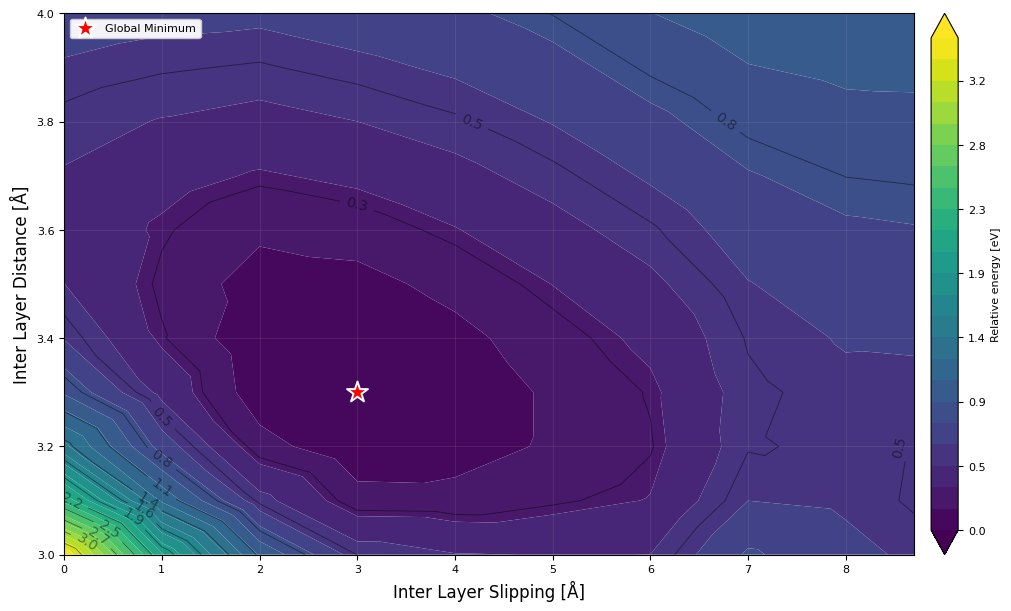

Saved: COF-1/3_COF-1_landscape/pes_COF-1_serr.png


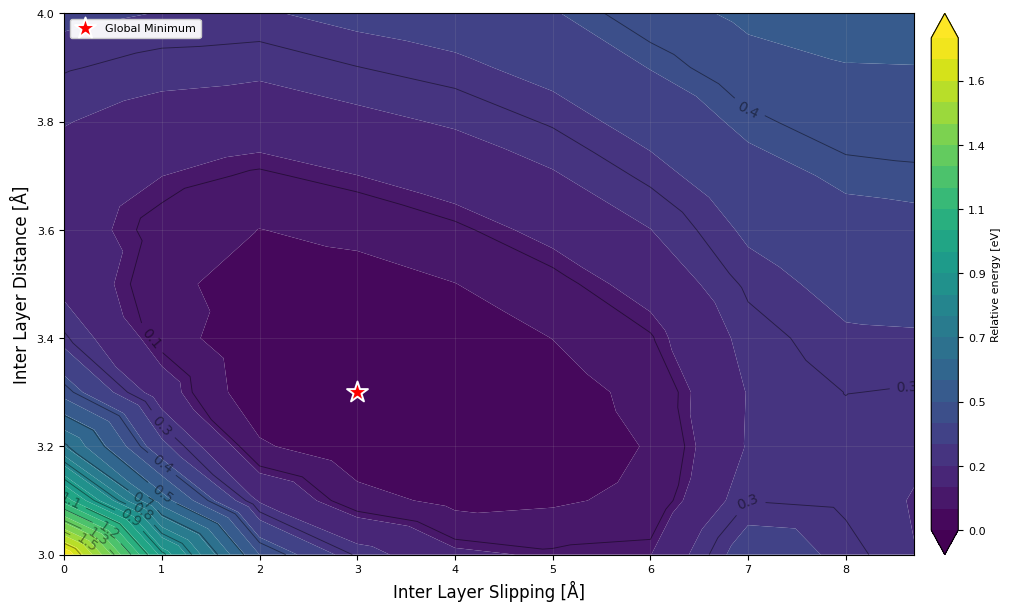

Saved: COF-1/3_COF-1_landscape/pes_COF-1_incl.png


In [7]:
landscape = cl.Landscape()
landscape.run_mode(cof_name=COF_NAME, mode=MODE, show=True)

### Structure Selection for Optimization

This step selects candidate structures corresponding to automatically detected local or gloabl minima are copies them into dedicated folders.

In [10]:
selector = cl.SelectCofs()
selector.run_mode(cof_name=COF_NAME, mode=MODE)


Selected ILD/ILS pairs (Serrated):
 ILD (Å)  ILS (Å)
     3.3      3.0

Selected ILD/ILS pairs (Inclined):
 ILD (Å)  ILS (Å)
     3.3      3.0


### MACE Geometry Optimization

This step performs geometry optimizations of selected stacking structures using `MaceOpt`.

`MaceOpt` uses ASE `FrechetCellFilter` + `LBFGS`, writes optimized CIF files, and can write a combined energy CSV (`{COF_NAME}_opt_energies_per_layer.csv`).

  Optimized structures (`.cif`) and optional energies CSV are written to:  
  `COF_NAME/4_{COF_NAME}_optimization/`

In [11]:
opt = cl.MaceOpt()
opt.run_mode(cof_name=COF_NAME, mode=MODE)

       Step     Time          Energy          fmax
LBFGS:    0 15:22:12   -62434.384809        0.412456
LBFGS:    1 15:22:14   -62434.395672        0.084911
LBFGS:    2 15:22:15   -62434.397278        0.060374
LBFGS:    3 15:22:17   -62434.399341        0.048978
LBFGS:    4 15:22:19   -62434.400183        0.046246
LBFGS:    5 15:22:21   -62434.400651        0.039567
LBFGS:    6 15:22:22   -62434.401077        0.035942
LBFGS:    7 15:22:24   -62434.401501        0.031583
LBFGS:    8 15:22:25   -62434.401879        0.028875
LBFGS:    9 15:22:27   -62434.402213        0.021961
LBFGS:   10 15:22:29   -62434.402514        0.023920
LBFGS:   11 15:22:30   -62434.402775        0.020655
LBFGS:   12 15:22:32   -62434.402981        0.015753
LBFGS:   13 15:22:34   -62434.403148        0.016498
LBFGS:   14 15:22:35   -62434.403311        0.016740
LBFGS:   15 15:22:37   -62434.403480        0.023132
LBFGS:   16 15:22:38   -62434.403620        0.020585
LBFGS:   17 15:22:40   -62434.403710        0.01

/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.004580711214139e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:    1 15:23:02   -31217.172006        0.167233


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 2.9865637893810596e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:    2 15:23:03   -31217.175724        0.112776


...

LBFGS:  115 15:24:45   -31217.201787        0.016523


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.003157858758749e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:  116 15:24:45   -31217.201840        0.013168


/Users/gregorlauter/Documents/PhD/2d-cof-mapper/COF-Landscaper/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1181: RuntimeWarning: logm result may be inaccurate, approximate err = 3.0611497191402364e-13
  return f(*arrays, *other_args, **kwargs)


LBFGS:  117 15:24:46   -31217.201877        0.009836
Saved optimized energies: COF-1/4_COF-1_optimization/COF-1_opt_energies_per_layer.csv


### Analysis & Visualization

This step analyzes optimized structures by computing interlayer distance (ILD) and interlayer slipping (ILS) from the optimized structures, and writing a summary CSV for comparison across stacking configurations.

In addition, structures can be visualized using an interactive viewer.

In [12]:
# Defaults
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode=MODE)

Serrated:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.3      3.0        0.0
Inclined:
 ILD (Å)  ILS (Å)  Erel (eV)
    3.2      3.0        0.0


In [13]:
# Defaults
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(cof_name=COF_NAME, mode=MODE)

Serrated | cof-1_z33_L030_serr.cif: ILD = 3.30 Å, ILS = 3.00 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Inclined | cof-1_z33_L030_incl.cif: ILD = 3.21 Å, ILS = 3.01 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

[<py3Dmol.view at 0x3638f61e0>, <py3Dmol.view at 0x363810da0>]

### PXRD Pattern Generation

This step simulates PXRD patterns from optimized CIF structures and writes per-structure `.xy` files.

---

#### Parameters

- `wavelength` *(str, optional, default: `CuKa`)*  
  X-ray source line used for simulation.  
  **Allowed values:** `CuKa`, `MoKa`, `CrKa`, `FeKa`, `CoKa`, `AgKa`  
  Choose this to match your instrument/source.

- `two_theta_range` *(tuple[float, float], optional, default: `(1.5, 60.0)`)*  
  Angular simulation window in degrees for generated `.xy` data.

- PXRD data (`.xy`) default written to:  
  `COF_NAME/5_{COF_NAME}_analysis/pxrd_xy/{serr|incl}/`


In [14]:
pxrd = cl.PXRD(wavelength="CuKa", two_theta_range=(1.5, 60.0))
pxrd.run(cof_name=COF_NAME, mode=MODE)

{'serr': 'COF-1/5_COF-1_analysis/pxrd_xy/serr',
 'incl': 'COF-1/5_COF-1_analysis/pxrd_xy/incl'}

### PXRD Peak Extraction

This step extracts the strongest simulated PXRD peaks from generated `.xy` files and writes peak tables.

---

#### Parameters

- `max_peaks` *(int, optional, default: `10`)*  
  Maximum number of peaks reported per structure.

- `min_relative_intensity` *(float, optional, default: `1.0`)*  
  Minimum relative intensity threshold in %. Peaks below this value are ignored.

- Peak tables (`.csv`) default written to:  
  `COF_NAME/5_{COF_NAME}_analysis/pxrd_peaks/{serr|incl}/`

In [15]:
pxrd.extract_peaks(cof_name=COF_NAME, mode=MODE)

{'serr':              structure  rank  two_theta_deg  relative_intensity
 0  cof-1_z33_L030_serr     1        6.78538             100.000
 1  cof-1_z33_L030_serr     2        6.78573              99.996
 2  cof-1_z33_L030_serr     3        6.78600              63.902
 3  cof-1_z33_L030_serr     4       27.01899              31.391
 4  cof-1_z33_L030_serr     5       15.04804               8.382
 5  cof-1_z33_L030_serr     6       15.04807               8.347
 6  cof-1_z33_L030_serr     7       27.88945               6.013
 7  cof-1_z33_L030_serr     8       11.76648               4.969
 8  cof-1_z33_L030_serr     9       15.04777               4.801
 9  cof-1_z33_L030_serr    10       13.59471               4.518,
 'incl':              structure  rank  two_theta_deg  relative_intensity
 0  cof-1_z33_L030_incl     1        7.50306             100.000
 1  cof-1_z33_L030_incl     2        7.50312              99.992
 2  cof-1_z33_L030_incl     3        9.33502              71.693
 3  cof-

### PXRD Plot

This step provides two plotting helpers:

- `plot_sim`  
  Stacked simulated PXRD patterns from `pxrd_xy/{serr|incl}` (or `pxrd_xy_dft/{serr|incl}` when `dft=True`).

- `plot_sim_vs_exp`  
  One experimental `.xy` file compared against every simulated `.xy` file in its own row.

#### Parameters

- `exp_xy_file` *(str or Path, optional, default: None)*  
  Path to the experimental `.xy` file.  
  **Default behavior:** If not provided, the folder `experimental_pxrd` (in the current directory) is searched for exactly one `.xy` file. If multiple `.xy` files exist, you must specify the exact path explicitly.  

- `xy_folder` for `plot_sim` or `simulated_xy_folder` for `plot_sim_vs_exp` *(str or Path, optional, default: None)*  
  Path to the simulated `.xy` files in their `MODE` subfolders.  
  **Custom labels:** To change the label displayed in the plot, simply rename your `.xy` file before passing it.

- `xlim` *(tuple[float, float], optional, default: `(1.5, 60.0)`)*  
  X-axis bounds as minimum and maximum 2θ range [º].

#### Output

- `plot_sim` writes `{COF_NAME}_sim_{serr|incl}.png`.  
- `plot_sim_vs_exp` writes `{COF_NAME}_{serr|incl|both}.png`.

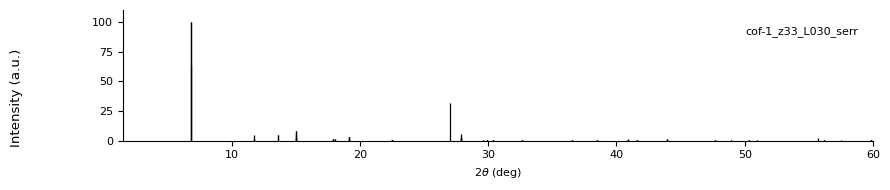

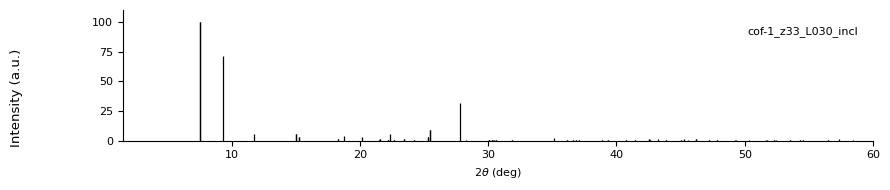

{'serr': 'COF-1/5_COF-1_analysis/COF-1_sim_serr.png',
 'incl': 'COF-1/5_COF-1_analysis/COF-1_sim_incl.png'}

In [16]:
pxrd.plot_sim(
    cof_name=COF_NAME,
    mode=MODE,
    xy_folder=None,
    xlim=(1.5, 60.0),
)

> 🚨 For a working example of `PXRD.plot_sim_vs_exp()`, please refer to the hybrid workflow example. Experimental `.xy` data for COF-1 were not available for me , so this functionality cannot be demonstrated here. But example code is demonstrated below.

### PXRD Plot

- `plot_sim_vs_exp`  
  One experimental `.xy` file compared against every simulated `.xy` file in its own row.

#### Parameters

- `xlim` *(tuple[float, float], optional, default: `(1.5, 60.0)`)*  
  X-axis bounds as minimum and maximum 2θ range [º].


#### Output

- `{COF_NAME}_{serr|incl|both}.png`.

In [ ]:
pxrd = cl.PXRD()
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    xlim=(1.5, 30.0),
)